In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../../data/placement.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


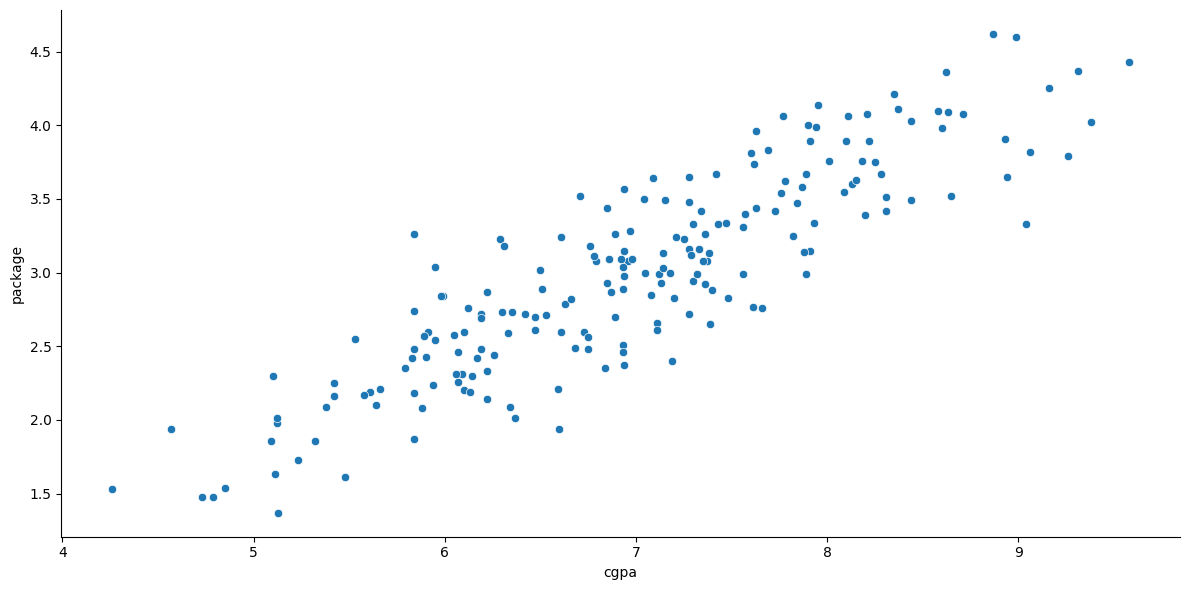

In [3]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x = 'cgpa', y='package')
sns.despine()
plt.tight_layout()
plt.show()

In [4]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

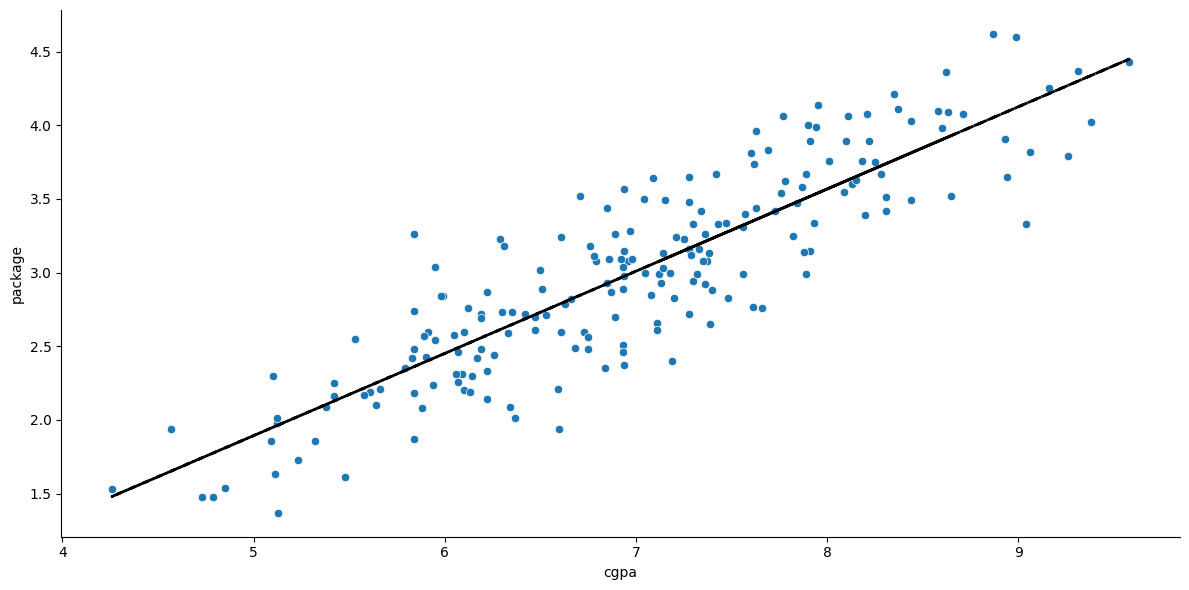

In [7]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x = 'cgpa', y='package')
plt.plot(X_train, model.predict(X_train), color='black', linewidth=2, linestyle='--', label='Regression Line')
sns.despine()
plt.tight_layout()
plt.show()

In [8]:
y_predict = model.predict(X_test)

In [9]:
print(f"MAE: {mean_absolute_error(y_test, y_predict)}")
print(f"MSE: {mean_squared_error(y_test, y_predict)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_predict)}")
print(f"R2 score: {r2_score(y_test, y_predict)}")

MAE: 0.2884710931878175
MSE: 0.12129235313495527
RMSE: 0.34827051717731616
R2 score: 0.780730147510384


In [10]:
#Adjusted R2 score

def adjusted_r2(y_test, y_pred, k):

    r2 = r2_score(y_test, y_pred)

    n = len(y_test)

    return 1 - (1 - r2) * ((n - 1) / (n - 1 - k))

In [11]:
adjusted_r2(y_test, y_predict, X_test.shape[1])

0.7749598882343415

In [12]:
new_df = df.copy()
new_df['random_feature'] = np.random.random(200)

new_df = new_df[['cgpa','random_feature','package']]
new_df.head()

,cgpa,random_feature,package
0,6.89,0.782141,3.26
1,5.12,0.543200,1.98
2,7.82,0.677542,3.25
3,7.42,0.511320,3.67
4,6.94,0.046653,3.57


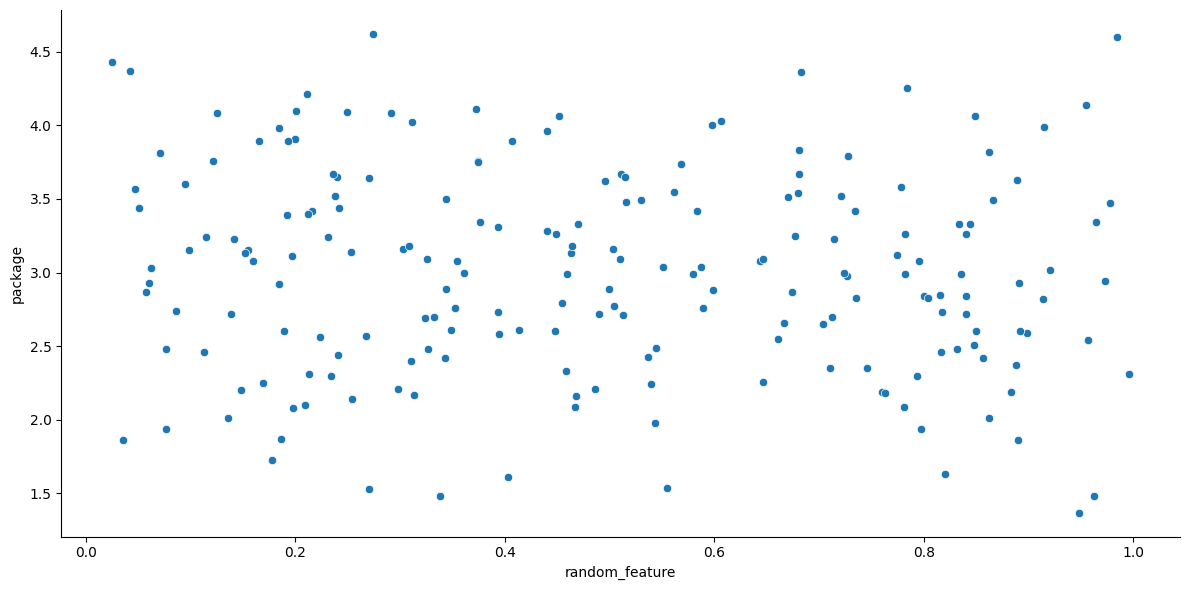

In [13]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=new_df, x = 'random_feature', y='package')
sns.despine()
plt.tight_layout()
plt.show()

In [14]:
X = new_df.iloc[:, 0:2]
y = new_df.iloc[:, -1]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
r2_score(y_test, y_pred)

0.7866230026486102

In [19]:
adjusted_r2(y_test, y_pred, X_test.shape[1])

0.7750891108998864